In [1]:

import glob
import pandas as pd
import os
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import re


from scipy.stats import spearmanr, pearsonr


In [2]:
def format_corr_with_stars(corr, p):
    if pd.isna(corr) or pd.isna(p):
        return ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    return f"{corr:.2f}{stars}"

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

In [3]:

def rename_model(x):
       if x == "OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42":
              return "Olmo2-1B"
       
def rename_estimator(x):
      return x.split(":")[0]
def rename_linear_coder(x):
      return x.replace("Coder","").replace("Thresh","")
def extract_seed(x):
       return int(re.search(r'seed (\d+)', x).group(1)) if "seed" in x else None

def rename_random(x):
    return re.sub(r' with seed \d+', "", x)



df_validation = pq.ParquetDataset("results/validation").read().to_pandas()
df_validation["model"]  = df_validation["model"].apply(rename_model)
df_validation["estimator"]  = df_validation["estimator"].apply(rename_estimator)


In [4]:
def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    first_number_match = re.match(r"^\s*(\d+)\b", explanation_type)
    if first_number_match:
        return int(first_number_match.group(1))


    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))

    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))

    return None

def replace_k(explanation_type, k):
    if k is None:
        return explanation_type
    # Only replace the first occurrence of the number as a standalone word
    return re.sub(rf"\b{k}\b", "X", explanation_type, count=1)

def vectorized_replace_k(explanation_types, ks):
    result = explanation_types.copy()
    for k in np.unique(ks[ks.notnull()]):  # only unique, non-null ks
        # Use string pattern, not compiled regex
        pattern = rf"\b{k}\b"
        mask = ks == k
        result.loc[mask] = result.loc[mask].str.replace(pattern, "X", n=1, regex=True)
    return result

def facility_location_hotfix(x):
    if ("facility" in x) and x.startswith("Top-"):
        return x[len("Top-"):]
    else:
        return x
def get_sort_type(x):
    for sort_type in ["scores with largest absolute value", "most positive scores", "most negative scores", "scores closest to zero"]:
        if sort_type in x:
            return sort_type
    return "-"





df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
df_validation["explanation_type_no_k"] = vectorized_replace_k(df_validation["explanation_type"], df_validation["k"])
df_validation["explanation_type"] = df_validation["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections



df_validation["sort_type"] = df_validation["explanation_type"].apply(get_sort_type)

df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]



In [5]:
df_scoring = pq.ParquetDataset("results/scoring").read().to_pandas()

df_scoring["NMSE"] =1.0 / (df_scoring["pred_gain"] + 1e-8)
df_scoring["k"] = df_scoring["explanation_type"].apply(extract_k)
df_scoring["explanation_type_no_k"] = df_scoring.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)
df_scoring["explanation_type"] = df_scoring["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections
df_scoring["model"] = df_scoring["model"].apply(rename_model)
df_scoring["estimator"] = df_scoring["estimator"].apply(rename_estimator)
df_scoring["fl"] = df_scoring["explanation_type"].apply(lambda x: "FL" if "facility" in x else "N")
import re

def get_lambda(x):
    match = re.search(r'lambda=([\d.]+)', x)
    return float(match.group(1)) if match else "-"

df_scoring["lambda"] = df_scoring["explanation_type"].apply(get_lambda)


In [6]:
# pair selection and random validation scores
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] >= r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] >= r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] >= r["kld(before||after)_random"]



In [7]:
# merge with our score
rr = pd.merge(
    r,
    df_scoring,
    left_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type_selection", 
        "k",
        "document_idx"
    ],
    right_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type", 
        "k",
        "document_idx"
    ],
    suffixes=("_validation", "_scoring"),
    how="left"
)


rr_summary = rr.groupby([
    "estimator",
    "explanation_type_selection",
    "model",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    "k",
    "linear_coder",
    "explanation_type_no_k_selection",
    "fl",
    "lambda"
]).agg(
    mean_NMSE=("NMSE", "mean"),
    mean_validation_score_log_p=("validation_score_log_p", "mean"),
    count_validation_score_log_p=("validation_score_log_p", "count"),
    mean_validation_score_jsd=("validation_score_jsd", "mean"),
    count_validation_score_jsd=("validation_score_jsd", "count"),
    mean_validation_score_kld=("validation_score_kld", "mean"),
    count_validation_score_kld=("validation_score_kld", "count")
)

                
                      
                

In [8]:
def compute_and_export_correlations(rr, rr_summary, subset_filter=None, group_cols=None, sort_cols=None,
                                    row_label_cols=None, filename="./tables/validation.tex", caption="Correlation table"):
    """
    Compute correlations of NMSE vs validation scores and export to LaTeX.
    
    subset_filter: function to filter rr and rr_summary (takes DataFrame, returns filtered DataFrame)
    group_cols: list of columns to group by
    sort_cols: list of columns to sort by in the final table
    row_label_cols: list of columns to use as row labels (index) in the table
    """

    rr_subset = rr.copy()
    rr_summary_subset = rr_summary.reset_index()
    if subset_filter:
        rr_subset = subset_filter(rr_subset)
        rr_summary_subset = subset_filter(rr_summary_subset)


    rows = []
    for keys, df in rr_subset.groupby(group_cols):
        if len(df) < 2:
            rows.append({**dict(zip(group_cols, keys)),
                         "spearman_NMSE_log_p": "",
                         "spearman_NMSE_jsd": "",
                         "pearson_NMSE_log_p": "",
                         "pearson_NMSE_jsd": ""})
            continue
        s_logp = spearmanr(df["NMSE"], df["validation_score_log_p"])
        s_jsd  = spearmanr(df["NMSE"], df["validation_score_jsd"])
        p_logp = pearsonr(df["NMSE"], df["validation_score_log_p"])
        p_jsd  = pearsonr(df["NMSE"], df["validation_score_jsd"])
        rows.append({**dict(zip(group_cols, keys)),
                     "spearman_NMSE_log_p": format_corr_with_stars(s_logp.correlation, s_logp.pvalue),
                     "spearman_NMSE_jsd": format_corr_with_stars(s_jsd.correlation, s_jsd.pvalue),
                     "pearson_NMSE_log_p": format_corr_with_stars(p_logp[0], p_logp[1]),
                     "pearson_NMSE_jsd": format_corr_with_stars(p_jsd[0], p_jsd[1])})

    pooled_df = pd.DataFrame(rows)

    if row_label_cols:
        pooled_df.set_index(row_label_cols, inplace=True)
    else:
        pooled_df.set_index(group_cols, inplace=True)

    correlation_cols = ["spearman_NMSE_log_p", "spearman_NMSE_jsd", "pearson_NMSE_log_p", "pearson_NMSE_jsd"]
    hidden_cols = [col for col in pooled_df.columns if col not in correlation_cols]

    colnames = {
        "spearman_NMSE_log_p": "$\\rho (NMSE, \\log_p)$",
        "spearman_NMSE_jsd": "$\\rho (NMSE, JSD)$",
        "pearson_NMSE_log_p": "$r (NMSE, \\log_p)$",
        "pearson_NMSE_jsd": "$r (NMSE, JSD)$"
    }

    styled = (
        pooled_df.sort_values(by=sort_cols or correlation_cols, ascending=True, na_position="last")
                 .style
                 .map(get_background_color_from_corr, subset=correlation_cols)
                 .map(get_text_color_for_contrast, subset=correlation_cols)
                 .format_index(colnames.get, axis=1)
                 .hide(axis="columns", subset=hidden_cols)
    )

 
    display(styled)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    latex_tabular = styled.to_latex(convert_css=True, hrules=True,
                                   column_format='l' + 'l' * len(styled.data.columns))
    latex_table = (
        "\\begin{table}[htbp]\n"
        "\\scriptsize\n"
        f"\\caption{{{caption}}}\\label{{tab:validation}}\n"
        "\\centering\n"
        f"{latex_tabular}\n"
        "\\end{table}\n"
    )
    with open(filename, "w") as f:
        f.write(latex_table)





## per linear coder

In [9]:
for linear_coder in df_scoring["linear_coder"].unique():
    print("linear_coder",linear_coder)
    compute_and_export_correlations(
        rr, rr_summary,
        group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","explanation_type","lambda","k"],
        subset_filter=lambda df: df[(df["lambda"]=="-")& (df["linear_coder"]==linear_coder)],
        row_label_cols=[ "k","estimator","explanation_type"],
        sort_cols=["k", "estimator","explanation_type"],
        filename=f"./tables/validation/per_linear_coder/{linear_coder}.tex",
        caption=f"Correlation of our score with validation scores for {linear_coder}"
    )

linear_coder KLTCoder


linear_coder MSECoderProjUSimpSparse


linear_coder MSECoder


linear_coder MSECoderProjUSimp


linear_coder MSECoderProjUSimpSparseSoftThresh


linear_coder MSECoderNNLSL2


## for MSECoderProjUSimpSparse

### mean per type

In [10]:

linear_coder = "MSECoderProjUSimp"
compute_and_export_correlations(
    rr, rr_summary,
    subset_filter=lambda df: df[(df["lambda"]=="-")& (df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","lambda", "explanation_type_no_k"],
    sort_cols=["lambda","estimator", "explanation_type_no_k"],
    row_label_cols=[ "explanation_type_no_k","estimator"],
    filename=f"./tables/validation/per_selection_type/{linear_coder}.tex",
    caption=f"Per selection-type correlation of our score with validation scores for {linear_coder}"
)



,,"$\rho (NMSE, \log_p)$","$\rho (NMSE, JSD)$","$r (NMSE, \log_p)$","$r (NMSE, JSD)$"
explanation_type_no_k,estimator,,,,
The test instance (as a sanity check),BM25Estimator,-0.10***,-0.15***,-0.65***,-0.52***
Top-X least influential (scores closest to zero),BM25Estimator,-0.01*,0.03***,-0.09***,-0.08***
Top-X most influential (scores with largest absolute value),BM25Estimator,-0.25***,-0.17***,-0.13***,-0.16***
The test instance (as a sanity check),DataInfEstimator,-0.09***,-0.14***,-0.60***,-0.50***
Top-X least influential (scores closest to zero),DataInfEstimator,-0.00,-0.01,-0.09***,-0.09***
Top-X most harmful (most positive scores),DataInfEstimator,-0.00,-0.05***,-0.08***,-0.10***
Top-X most helpful (most negative scores),DataInfEstimator,-0.03***,-0.06***,-0.08***,-0.08***
Top-X most influential (scores with largest absolute value),DataInfEstimator,-0.02*,-0.10***,-0.08***,-0.10***
The test instance (as a sanity check),LESSEstimator,-0.10***,-0.16***,-0.63***,-0.47***


### mean per k

In [11]:

linear_coder = "MSECoderProjUSimp"
compute_and_export_correlations(
    rr, rr_summary,
    subset_filter=lambda df: df[(df["lambda"]=="-")& (df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","lambda", "k"],
    sort_cols=[ "k","lambda","estimator",],
    row_label_cols=[ "k","estimator"],
    filename=f"./tables/validation/per_k/{linear_coder}.tex",
    caption=f"Per k correlation of our score with validation scores for {linear_coder}"
)



### mean per estimator

In [12]:

linear_coder = "MSECoderProjUSimp"
compute_and_export_correlations(
    rr, rr_summary,
    subset_filter=lambda df: df[(df["lambda"]=="-")& (df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","lambda",],
    sort_cols=[ "lambda","estimator",],
    row_label_cols=[ "estimator"],
    filename=f"./tables/validation/per_estimator/{linear_coder}.tex",
    caption=f"Per estimatior correlation of our score with validation scores for {linear_coder}"
)



,"$\rho (NMSE, \log_p)$","$\rho (NMSE, JSD)$","$r (NMSE, \log_p)$","$r (NMSE, JSD)$"
estimator,,,,
BM25Estimator,-0.28***,-0.25***,-0.12***,-0.12***
DataInfEstimator,-0.10***,-0.09***,-0.09***,-0.10***
LESSEstimator,-0.11***,-0.09***,-0.08***,-0.10***


### mean per lambda

In [13]:

linear_coder = "MSECoderProjUSimp"
compute_and_export_correlations(
    rr, rr_summary,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","lambda",],
    sort_cols=[ "lambda","estimator",],
    row_label_cols=[ "estimator", "lambda"],
    filename=f"./tables/validation/per_lambda/{linear_coder}.tex",
    caption=f"Per lambda correlation of our score with validation scores for {linear_coder}"
)



,,"$\rho (NMSE, \log_p)$","$\rho (NMSE, JSD)$","$r (NMSE, \log_p)$","$r (NMSE, JSD)$"
estimator,lambda,,,,
BM25Estimator,0.000000,0.03***,0.06***,-0.10***,-0.10***
DataInfEstimator,0.000000,-0.02***,0.03***,-0.09***,-0.09***
LESSEstimator,0.000000,-0.02***,0.00,-0.09***,-0.10***
BM25Estimator,0.250000,-0.08***,-0.04***,-0.10***,-0.09***
DataInfEstimator,0.250000,-0.00,0.03***,-0.08***,-0.09***
LESSEstimator,0.250000,-0.01*,0.02***,-0.08***,-0.09***
BM25Estimator,0.500000,-0.02***,-0.01,-0.10***,-0.10***
DataInfEstimator,0.500000,-0.02***,0.02***,-0.08***,-0.09***
LESSEstimator,0.500000,-0.02***,0.02***,-0.09***,-0.09***


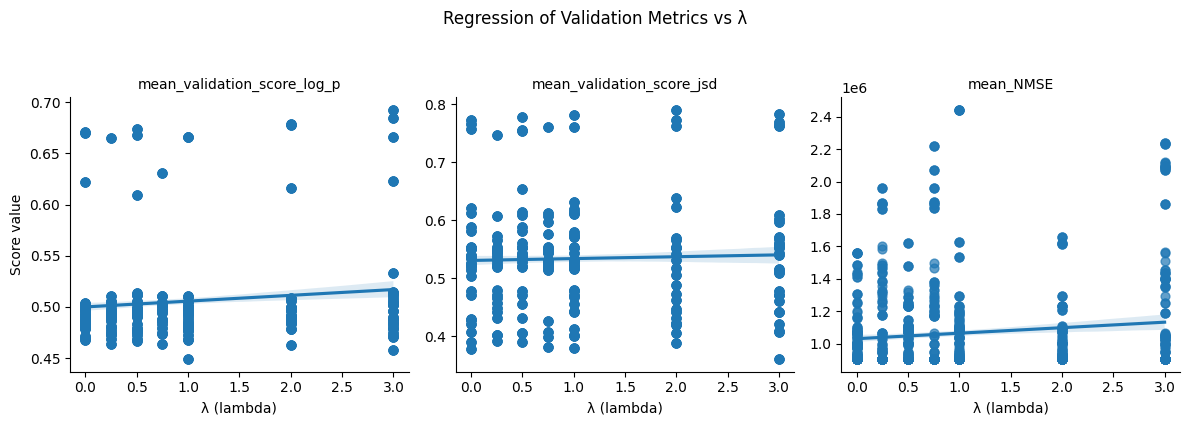

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
da = rr_summary.reset_index()
da.explanation_type_selection.unique()
da["lambda"] = da["lambda"].apply(lambda x: x if x != "-" else None) 
# Melt the data to long format for FacetGrid
da_long = da.melt(id_vars="lambda", 
                  value_vars=["mean_validation_score_log_p", "mean_validation_score_jsd", "mean_NMSE"],
                  var_name="metric", 
                  value_name="score")

# Create the FacetGrid (one facet per metric)
g = sns.FacetGrid(da_long, col="metric", col_wrap=3, sharex=True, sharey=False, height=4)
g.map_dataframe(sns.regplot, x="lambda", y="score", scatter_kws={"s": 40, "alpha": 0.7})

# Adjust titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("λ (lambda)", "Score value")
g.fig.suptitle("Regression of Validation Metrics vs λ", y=1.05)
plt.tight_layout()
plt.show()


Pearson correlation (mean_NMSE vs mean_validation_score_jsd): -0.004
Pearson correlation (mean_NMSE vs mean_validation_score_log_p): -0.111
spearman_jsd: 0.016
spearman_logp: 0.112
spearman_NMSE: 0.040

--- mean_validation_score_log_p ---
Pearson r = 0.113, p = 1.419e-04
Spearman r = 0.112, p = 1.697e-04

--- mean_validation_score_jsd ---
Pearson r = 0.033, p = 2.669e-01
Spearman r = 0.016, p = 5.935e-01

--- mean_NMSE ---
Pearson r = 0.117, p = 8.337e-05
Spearman r = 0.040, p = 1.775e-01


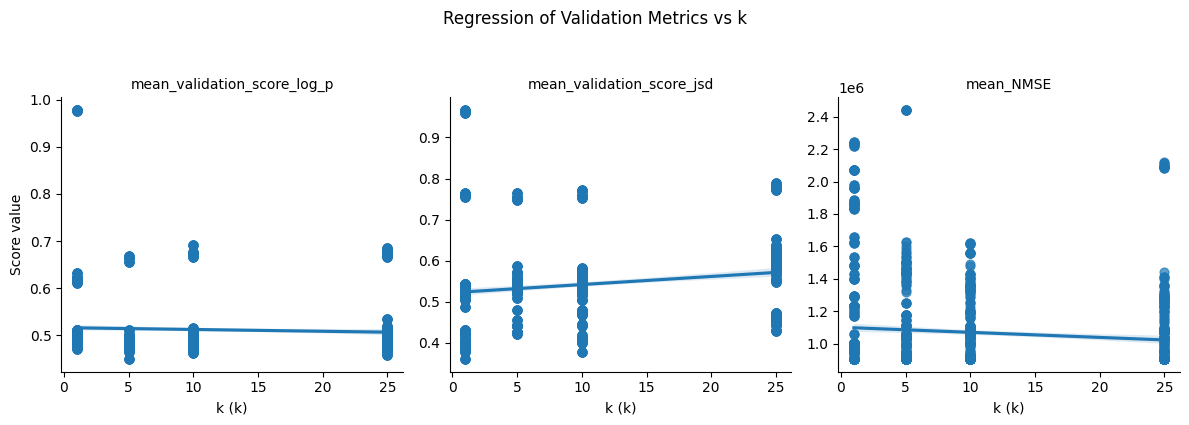

spearman_jsd: 0.283
spearman_logp: -0.201
spearman_NMSE: -0.039


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

# Compute correlation coefficients
corr_jsd = da["mean_NMSE"].corr(da["mean_validation_score_jsd"], method="pearson")
corr_logp = da["mean_NMSE"].corr(da["mean_validation_score_log_p"], method="pearson")

print(f"Pearson correlation (mean_NMSE vs mean_validation_score_jsd): {corr_jsd:.3f}")
print(f"Pearson correlation (mean_NMSE vs mean_validation_score_log_p): {corr_logp:.3f}")

corrs = {
    "spearman_jsd": da["lambda"].corr(da["mean_validation_score_jsd"], method="spearman"),
    "spearman_logp": da["lambda"].corr(da["mean_validation_score_log_p"], method="spearman"),
    "spearman_NMSE": da["lambda"].corr(da["mean_NMSE"], method="spearman"),
}

for k, v in corrs.items():
    print(f"{k}: {v:.3f}")

metrics = [
    "mean_validation_score_log_p",
    "mean_validation_score_jsd",
    "mean_NMSE"
]

for m in metrics:
    # Drop NaNs for safety
    subset = da[["lambda", m]].dropna()
    x = subset["lambda"]
    y = subset[m]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    print(f"\n--- {m} ---")
    print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
    print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

# Melt the data to long format for FacetGrid
da_long = da.melt(id_vars="k", 
                  value_vars=["mean_validation_score_log_p", "mean_validation_score_jsd", "mean_NMSE"],
                  var_name="metric", 
                  value_name="score")

# Create the FacetGrid (one facet per metric)
g = sns.FacetGrid(da_long, col="metric", col_wrap=3, sharex=True, sharey=False, height=4)
g.map_dataframe(sns.regplot, x="k", y="score", scatter_kws={"s": 40, "alpha": 0.7})

# Adjust titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("k (k)", "Score value")
g.fig.suptitle("Regression of Validation Metrics vs k", y=1.05)
plt.tight_layout()
plt.show()

corrs = {
    "spearman_jsd": da["k"].corr(da["mean_validation_score_jsd"], method="spearman"),
    "spearman_logp": da["k"].corr(da["mean_validation_score_log_p"], method="spearman"),
    "spearman_NMSE": da["k"].corr(da["mean_NMSE"], method="spearman"),
}

for k, v in corrs.items():
    print(f"{k}: {v:.3f}")
